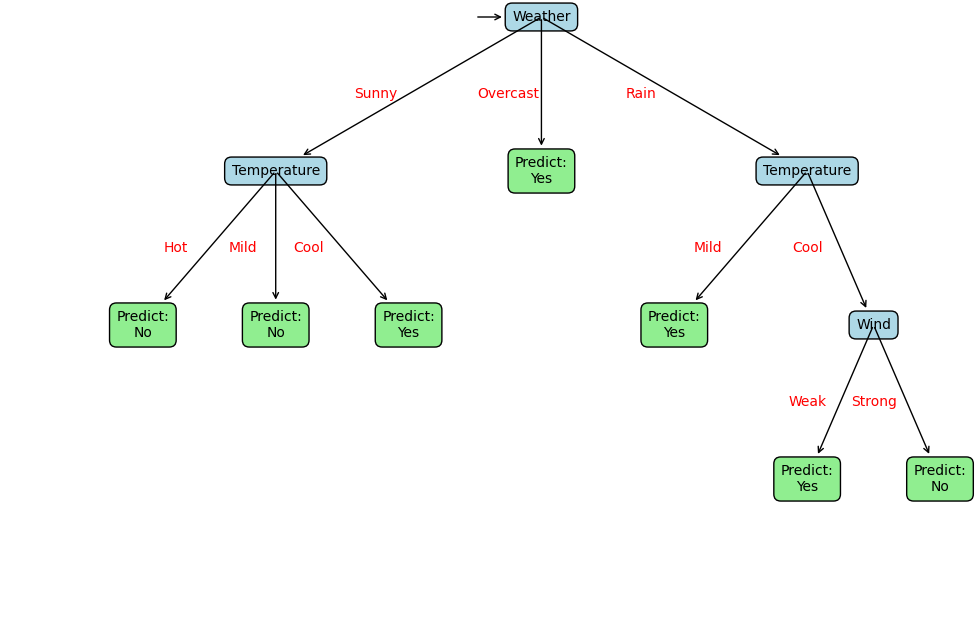

In [5]:
import pandas as pd
import math
import matplotlib.pyplot as plt

def entropy(data, target_col):
    counts = data[target_col].value_counts()
    total = len(data)
    ent = 0
    for count in counts:
        p = count / total
        ent -= p * math.log2(p)
    return ent

def info_gain(data, feature, target_col):
    total_entropy = entropy(data, target_col)
    values = data[feature].unique()
    weighted_entropy = 0
    for val in values:
        subset = data[data[feature] == val]
        weighted_entropy += (len(subset) / len(data)) * entropy(subset, target_col)
    return total_entropy - weighted_entropy

def majority_class(data, target_col):
    return data[target_col].mode()[0]

def id3(data, features, target_col, depth=0, max_depth=None):
    labels = data[target_col].unique()
    
    if len(labels) == 1:
        return {'label': labels[0]}
    
    if len(features) == 0 or (max_depth is not None and depth >= max_depth):
        return {'label': majority_class(data, target_col)}
    
    gains = [(feature, info_gain(data, feature, target_col)) for feature in features]
    best_feature, best_gain = max(gains, key=lambda x: x[1])
    
    if best_gain == 0:
        return {'label': majority_class(data, target_col)}
    
    tree = {'feature': best_feature, 'nodes': {}}
    remaining_features = [f for f in features if f != best_feature]
    
    for val in data[best_feature].unique():
        subset = data[data[best_feature] == val]
        if subset.empty:
            tree['nodes'][val] = {'label': majority_class(data, target_col)}
        else:
            subtree = id3(subset, remaining_features, target_col, depth + 1, max_depth)
            tree['nodes'][val] = subtree
    return tree



def plot_node(text, center_point, parent_point, ax, node_type='decision'):

    box_style = dict(boxstyle="round,pad=0.5", fc="lightblue" if node_type=='decision' else "lightgreen")
    ax.annotate(text,
                xy=parent_point, xycoords='axes fraction',
                xytext=center_point, textcoords='axes fraction',
                va="center", ha="center",
                bbox=box_style,
                arrowprops=dict(arrowstyle="<-"))

def get_num_leaves(tree):
    if 'label' in tree:
        return 1
    leaves = 0
    for subtree in tree['nodes'].values():
        leaves += get_num_leaves(subtree)
    return leaves

def get_tree_depth(tree):
    if 'label' in tree:
        return 1
    depths = []
    for subtree in tree['nodes'].values():
        depths.append(1 + get_tree_depth(subtree))
    return max(depths)

def plot_tree(tree, parent_point, node_text, ax, total_w, total_d, x_off, y_off):
    num_leaves = get_num_leaves(tree)
    depth = get_tree_depth(tree)
    

    center_point = (x_off + (1.0 + num_leaves) / (2.0 * total_w), y_off)

    if 'label' in tree:
        plot_node(f"Predict:\n{tree['label']}", center_point, parent_point, ax, node_type='leaf')
    else:
        plot_node(f"{tree['feature']}", center_point, parent_point, ax, node_type='decision')
    

    if 'nodes' in tree:
        y_off_new = y_off - 1.0 / total_d
        for val, subtree in tree['nodes'].items():

            num_leaves_sub = get_num_leaves(subtree)
            x_off_new = x_off
            plot_tree(subtree, center_point, str(val), ax, total_w, total_d, x_off_new, y_off_new)
            x_off += num_leaves_sub / total_w

            mid_x = (center_point[0] + x_off_new + num_leaves_sub / (2.0 * total_w)) / 2
            mid_y = (center_point[1] + y_off_new) / 2
            ax.text(mid_x, mid_y, str(val), va='center', ha='center', color='red', fontsize=10)

def draw_tree(tree):
    fig, ax = plt.subplots(figsize=(12,8))
    ax.axis('off')
    total_w = get_num_leaves(tree)
    total_d = get_tree_depth(tree)
    plot_tree(tree, (0.5,1.0), '', ax, total_w, total_d, 0.0, 1.0)
    plt.show()

data = {
    'Weather': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Strong'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes']
}

df = pd.DataFrame(data)
features = list(df.columns[:-1])
target_col = 'PlayTennis'

tree = id3(df, features, target_col)
draw_tree(tree)


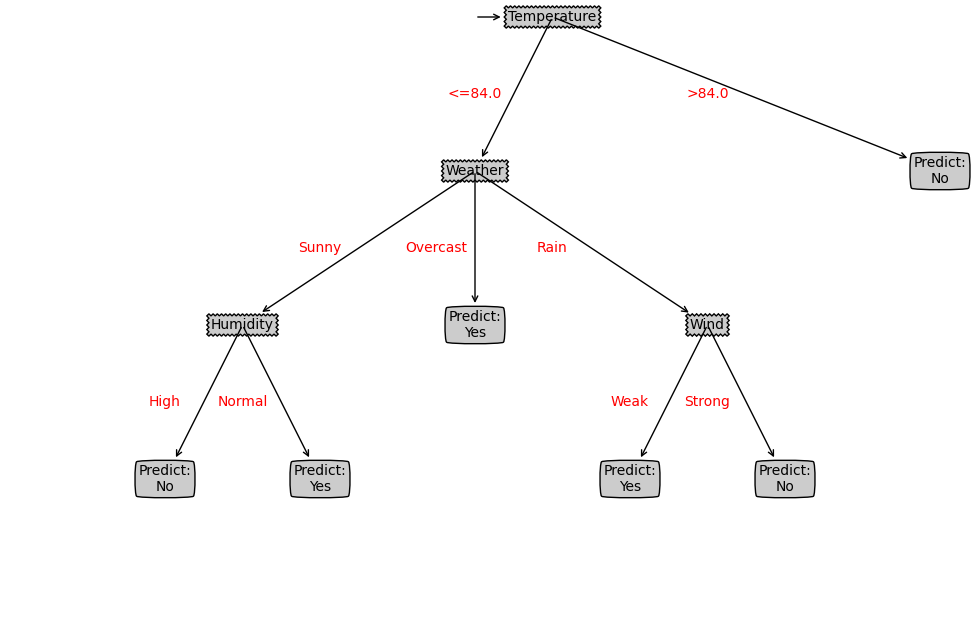

In [4]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt

def entropy(data, target_col):
    counts = data[target_col].value_counts()
    total = len(data)
    ent = 0
    for count in counts:
        p = count / total
        ent -= p * math.log2(p)
    return ent

def split_numeric(data, feature, target_col):

    data_sorted = data.sort_values(feature).reset_index(drop=True)
    unique_vals = data_sorted[feature].unique()
    best_threshold = None
    best_gain_ratio = -1
    base_entropy = entropy(data, target_col)
    
    for i in range(len(unique_vals) - 1):
        threshold = (unique_vals[i] + unique_vals[i+1]) / 2
        left = data_sorted[data_sorted[feature] <= threshold]
        right = data_sorted[data_sorted[feature] > threshold]
        
        left_weight = len(left) / len(data)
        right_weight = len(right) / len(data)
        new_entropy = left_weight * entropy(left, target_col) + right_weight * entropy(right, target_col)
        
        info_gain = base_entropy - new_entropy

        split_info = 0
        for subset in [left, right]:
            p = len(subset) / len(data)
            if p > 0:
                split_info -= p * math.log2(p)

        if split_info == 0:
            continue
        
        gain_ratio = info_gain / split_info
        
        if gain_ratio > best_gain_ratio:
            best_gain_ratio = gain_ratio
            best_threshold = threshold

    return best_gain_ratio, best_threshold

def split_categorical(data, feature, target_col):
    base_entropy = entropy(data, target_col)
    values = data[feature].unique()
    
    weighted_entropy = 0
    split_info = 0
    
    for val in values:
        subset = data[data[feature] == val]
        weight = len(subset) / len(data)
        weighted_entropy += weight * entropy(subset, target_col)
        split_info -= weight * math.log2(weight) if weight > 0 else 0
    
    info_gain = base_entropy - weighted_entropy
    
    if split_info == 0:
        return 0, None
    
    gain_ratio = info_gain / split_info
    return gain_ratio, None

def majority_class(data, target_col):
    return data[target_col].mode()[0]

def is_numeric(series):
    return pd.api.types.is_numeric_dtype(series)

def c45(data, features, target_col, depth=0, max_depth=None):
    labels = data[target_col].unique()
    if len(labels) == 1:
        return {'label': labels[0]}
    
    if len(features) == 0 or (max_depth is not None and depth >= max_depth):
        return {'label': majority_class(data, target_col)}
    
    best_feature = None
    best_gain_ratio = -1
    best_threshold = None
    is_best_numeric = False
    
    for feature in features:
        if is_numeric(data[feature]):
            gain_ratio, threshold = split_numeric(data, feature, target_col)
            if gain_ratio > best_gain_ratio:
                best_gain_ratio = gain_ratio
                best_feature = feature
                best_threshold = threshold
                is_best_numeric = True
        else:
            gain_ratio, _ = split_categorical(data, feature, target_col)
            if gain_ratio > best_gain_ratio:
                best_gain_ratio = gain_ratio
                best_feature = feature
                best_threshold = None
                is_best_numeric = False
    
    if best_gain_ratio <= 0:
        return {'label': majority_class(data, target_col)}
    
    tree = {'feature': best_feature}
    if is_best_numeric:
        tree['threshold'] = best_threshold
        tree['nodes'] = {}
        left_subset = data[data[best_feature] <= best_threshold]
        right_subset = data[data[best_feature] > best_threshold]
        remaining_features = [f for f in features if f != best_feature]
        
        tree['nodes']['<=' + str(round(best_threshold, 3))] = c45(left_subset, remaining_features, target_col, depth + 1, max_depth)
        tree['nodes']['>' + str(round(best_threshold, 3))] = c45(right_subset, remaining_features, target_col, depth + 1, max_depth)
    else:
        tree['nodes'] = {}
        remaining_features = [f for f in features if f != best_feature]
        for val in data[best_feature].unique():
            subset = data[data[best_feature] == val]
            if subset.empty:
                tree['nodes'][val] = {'label': majority_class(data, target_col)}
            else:
                tree['nodes'][val] = c45(subset, remaining_features, target_col, depth + 1, max_depth)
    
    return tree
def get_num_leaves(tree):
    if 'label' in tree:
        return 1
    leaves = 0
    for subtree in tree['nodes'].values():
        leaves += get_num_leaves(subtree)
    return leaves

def get_tree_depth(tree):
    if 'label' in tree:
        return 1
    depths = []
    for subtree in tree['nodes'].values():
        depths.append(1 + get_tree_depth(subtree))
    return max(depths)
def draw_tree(tree):
    fig, ax = plt.subplots(figsize=(12,8))
    ax.axis('off')
    total_w = get_num_leaves(tree)
    total_d = get_tree_depth(tree)
    plot_tree(tree, (0.5,1.0), '', ax, total_w, total_d, 0.0, 1.0)
    plt.show()
def plot_tree(tree, parent_point, node_text, ax, total_w, total_d, x_off, y_off):
    num_leaves = get_num_leaves(tree)
    depth = get_tree_depth(tree)
    

    center_point = (x_off + (1.0 + num_leaves) / (2.0 * total_w), y_off)

    if 'label' in tree:
        plot_node(f"Predict:\n{tree['label']}", center_point, parent_point, ax, node_type='leaf')
    else:
        plot_node(f"{tree['feature']}", center_point, parent_point, ax, node_type='decision')
    

    if 'nodes' in tree:
        y_off_new = y_off - 1.0 / total_d
        for val, subtree in tree['nodes'].items():

            num_leaves_sub = get_num_leaves(subtree)
            x_off_new = x_off
            plot_tree(subtree, center_point, str(val), ax, total_w, total_d, x_off_new, y_off_new)
            x_off += num_leaves_sub / total_w

            mid_x = (center_point[0] + x_off_new + num_leaves_sub / (2.0 * total_w)) / 2
            mid_y = (center_point[1] + y_off_new) / 2
            ax.text(mid_x, mid_y, str(val), va='center', ha='center', color='red', fontsize=10)

def plot_node(node_txt, center_pt, parent_pt, ax, node_type):
    if node_type == 'decision':
        box_style = dict(boxstyle="sawtooth", fc="0.8")
    else:
        box_style = dict(boxstyle="round4", fc="0.8")

    ax.annotate(node_txt, xy=parent_pt, xycoords='axes fraction',
                xytext=center_pt, textcoords='axes fraction',
                va="center", ha="center", bbox=box_style, arrowprops=dict(arrowstyle="<-"))
data = {
    'Weather': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain'],
    'Temperature': [85, 80, 83, 70, 68, 65, 64, 72, 69, 75],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Strong'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes']
}

df = pd.DataFrame(data)
features = list(df.columns[:-1])
target_col = 'PlayTennis'

tree = c45(df, features, target_col)
draw_tree(tree)

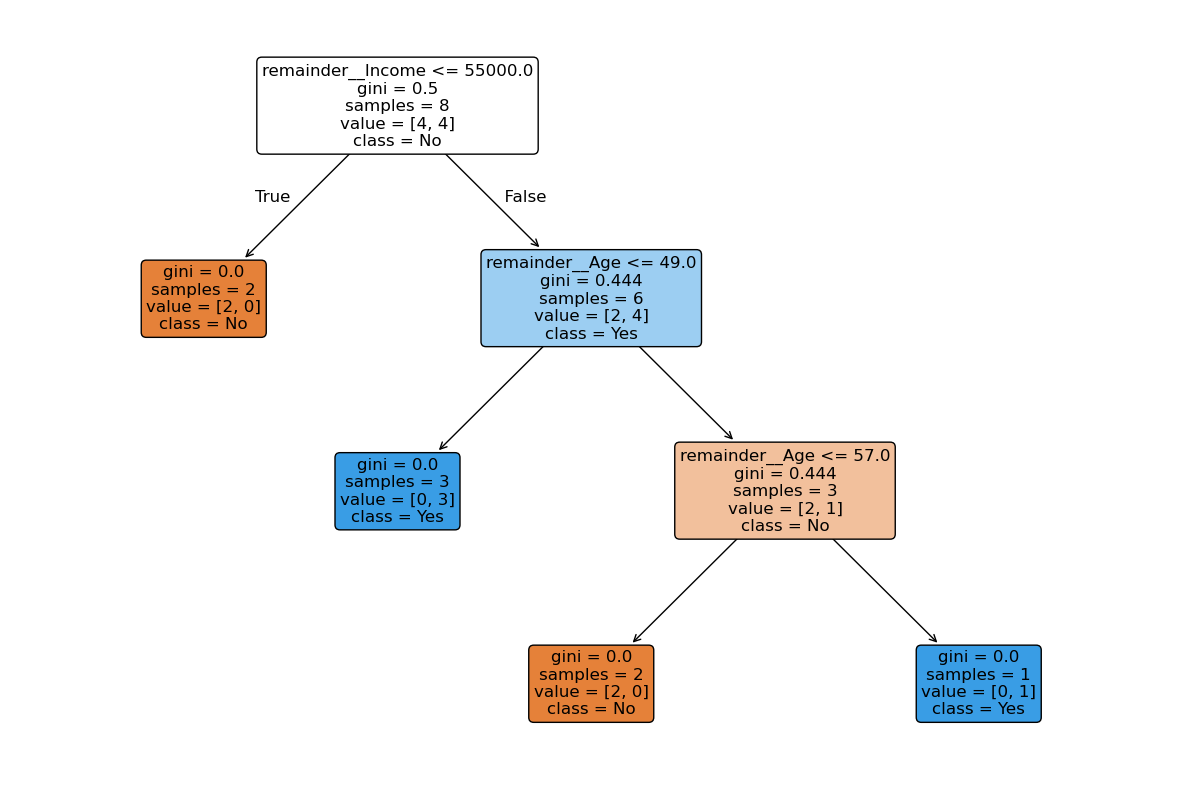

In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

data = {
    'Age': [25, 32, 47, 51, 62, 23, 43, 52],
    'Income': [50000, 60000, 80000, 90000, 120000, 40000, 70000, 95000],
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Male', 'Female', 'Female', 'Male'],
    'City': ['New York', 'Paris', 'Paris', 'New York', 'New York', 'Paris', 'London', 'London'],
    'Buy': ['No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No']  # Target variable
}

df = pd.DataFrame(data)

X = df.drop('Buy', axis=1)
y = df['Buy']

categorical_features = ['Gender', 'City']
numeric_features = ['Age', 'Income']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_features)
    ],
    remainder='passthrough'
)

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42))
])

clf.fit(X, y)

plt.figure(figsize=(15,10))
plot_tree(
    clf.named_steps['classifier'],
    feature_names=clf.named_steps['preprocessor'].get_feature_names_out(),
    class_names=clf.named_steps['classifier'].classes_,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.show()